# World Cup 2026 Simulation
This will be with 3 models (the highest performing on validation data):
- Logistic Regression (n=10)
- XGBoost (n=10)
- XGBoost (n=20)

## Retrain Top 3 Models

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.preprocessing import StandardScaler

MODEL_DATA_DIR = Path('model_data')

N_VALUES = [5, 10, 15, 20]

FEATURES = [
    'elo_diff',
    'form_diff',
    'comp_form_diff'
]

def load_and_engineer(path):
    df = pd.read_csv(path)
    df['elo_diff']       = df['home_elo']       - df['away_elo']
    df['form_diff']      = df['home_form']       - df['away_form']
    df['comp_form_diff'] = df['home_comp_form']  - df['away_comp_form']
    return df


### Train Logistic Regression (n=10)

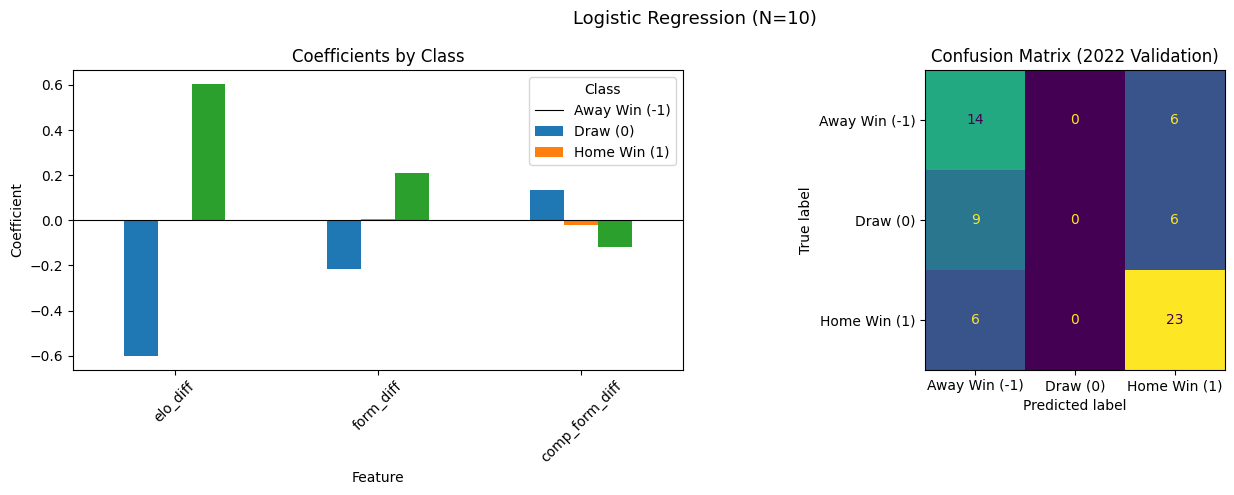

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

train = load_and_engineer(MODEL_DATA_DIR / 'training_data_10.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_10.csv')

scaler = StandardScaler()
X_train = scaler.fit_transform(train[FEATURES])
X_val   = scaler.transform(val[FEATURES])
y_train, y_val = train['result'], val['result']

lr_best = LogisticRegression(random_state=42, max_iter=1000)
lr_best.fit(X_train, y_train)

LABELS = ['Away Win (-1)', 'Draw (0)', 'Home Win (1)']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Logistic Regression (N=10)', fontsize=13)

# Coefficient bar chart — one set of coefficients per class
coef_df = pd.DataFrame(lr_best.coef_, columns=FEATURES, index=lr_best.classes_)
coef_df.T.plot(kind='bar', ax=axes[0])
axes[0].set_title('Coefficients by Class')
axes[0].set_xlabel('Feature')
axes[0].set_ylabel('Coefficient')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Class', labels=LABELS)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_val, lr_best.predict(X_val),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

### Train XGBoost (n=10, 20)

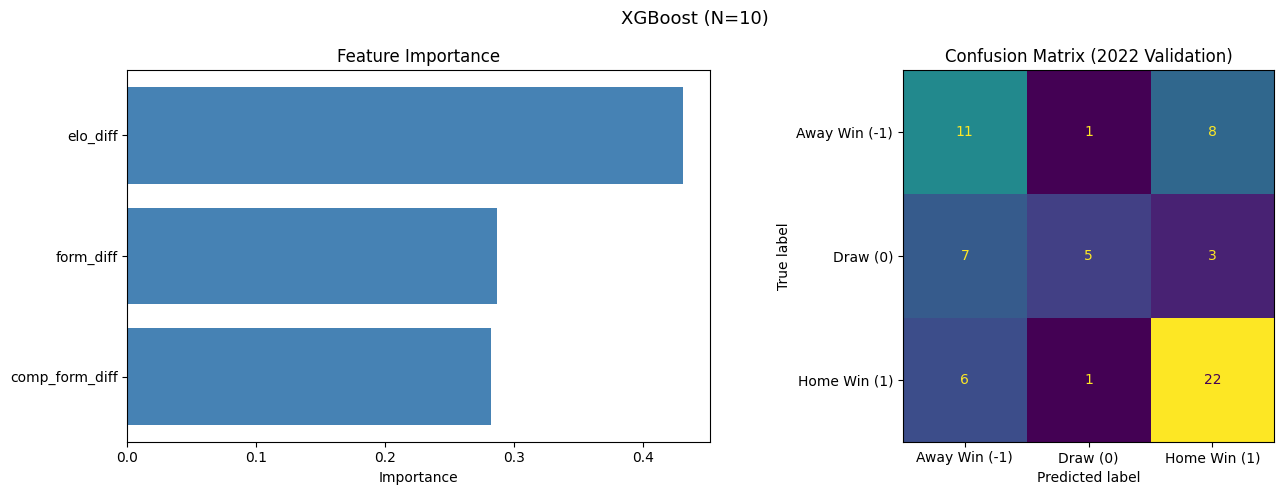

In [3]:
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

xgb_results = []

# Encode labels to 0,1,2 as XGBoost requires non-negative integer classes
le = LabelEncoder()

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values) # type: ignore
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values) # type: ignore

xgb_best_10 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_10.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=10)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_10.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_10.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

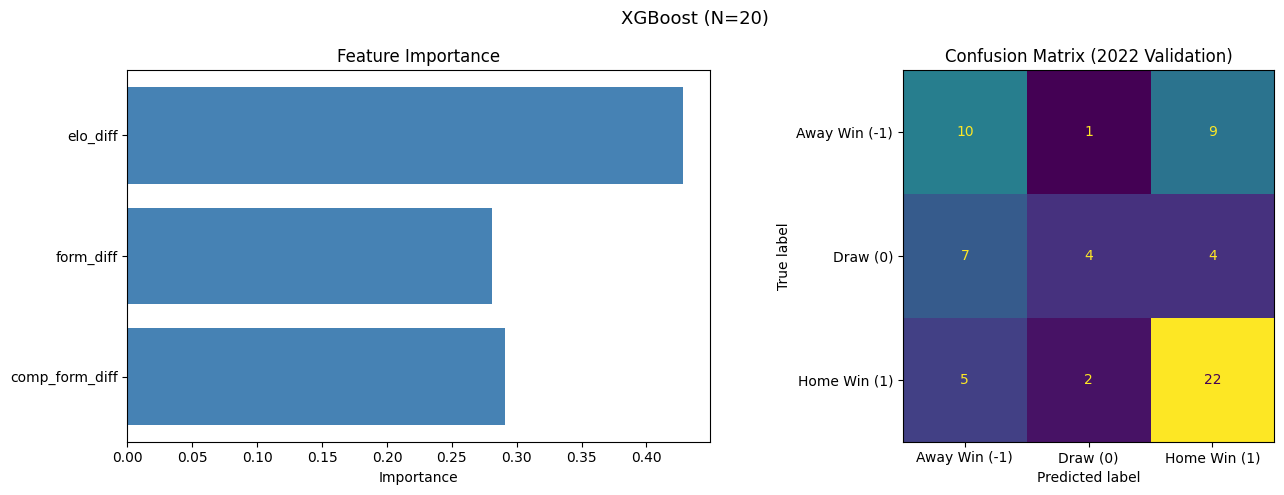

In [4]:
train = load_and_engineer(MODEL_DATA_DIR / 'training_data_20.csv')
val   = load_and_engineer(MODEL_DATA_DIR / 'validation_data_20.csv')

X_train, y_train = train[FEATURES].values, le.fit_transform(train['result'].values)
X_val,   y_val   = val[FEATURES].values,   le.transform(val['result'].values)

xgb_best_20 = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.1,
    subsample=0.8, reg_lambda=2.0,
    random_state=42, eval_metric='mlogloss', verbosity=0,
)
xgb_best_20.fit(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('XGBoost (N=20)', fontsize=13)

# Feature importance
axes[0].barh(FEATURES, xgb_best_20.feature_importances_, color='steelblue')
axes[0].set_title('Feature Importance')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

# Confusion matrix — decode labels back to -1/0/1 for display
ConfusionMatrixDisplay.from_predictions(
    le.inverse_transform(y_val), le.inverse_transform(xgb_best_20.predict(X_val)),
    display_labels=LABELS,
    ax=axes[1], colorbar=False
)
axes[1].set_title('Confusion Matrix (2022 Validation)')

plt.tight_layout()
plt.show()

## Monte Carlo Simulation for Each Model
(10,000x)

### Logistic Regression (n=10)

In [5]:
import random

N_SIMS = 10_000

fixtures_lr = pd.read_csv(MODEL_DATA_DIR / 'fixtures_2026_n10.csv')

# Get model probabilities for each fixture — classes are [-1, 0, 1]
X_fixtures = scaler.transform(fixtures_lr[FEATURES].values)
probs_lr = lr_best.predict_proba(X_fixtures)  # shape (72, 3), columns = [-1, 0, 1]
classes = list(lr_best.classes_)              # [-1, 0, 1]

# Attach probs to fixtures for easy lookup
fixtures_lr['p_away'] = probs_lr[:, classes.index(-1)]
fixtures_lr['p_draw'] = probs_lr[:, classes.index(0)]
fixtures_lr['p_home'] = probs_lr[:, classes.index(1)]

GROUPS = sorted(fixtures_lr['group'].unique())

# Accumulate points per team per simulation
sim_points = {g: {} for g in GROUPS}
for g in GROUPS:
    teams = pd.unique(fixtures_lr[fixtures_lr['group'] == g][['home_team', 'away_team']].values.ravel())
    sim_points[g] = {t: np.zeros(N_SIMS) for t in teams}

for sim in range(N_SIMS):
    for _, row in fixtures_lr.iterrows():
        outcome = random.choices([-1, 0, 1], weights=[row['p_away'], row['p_draw'], row['p_home']])[0]
        if outcome == 1:    # home win
            sim_points[row['group']][row['home_team']][sim] += 3
        elif outcome == -1: # away win
            sim_points[row['group']][row['away_team']][sim] += 3
        else:               # draw
            sim_points[row['group']][row['home_team']][sim] += 1
            sim_points[row['group']][row['away_team']][sim] += 1

# Average expected points across simulations
print('=== Logistic Regression (N=10) — Expected Group Points ===\n')
group_tables_lr = {}
for g in GROUPS:
    rows = [{'team': t, 'expected_pts': round(float(np.mean(pts)), 2)}
            for t, pts in sim_points[g].items()]
    table = pd.DataFrame(rows).sort_values('expected_pts', ascending=False).reset_index(drop=True)
    table.index += 1
    group_tables_lr[g] = table
    print(f'Group {g}')
    print(table.to_string())
    print()

/Users/stefanilic/Documents/GitHub/world-cup-predictions/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


=== Logistic Regression (N=10) — Expected Group Points ===

Group A
             team  expected_pts
1          Mexico          5.48
2     South Korea          4.79
3  Czech Republic          4.19
4    South Africa          2.08

Group B
                     team  expected_pts
1             Switzerland          6.76
2                  Canada          5.65
3  Bosnia and Herzegovina          3.12
4                   Qatar          1.28

Group C
       team  expected_pts
1    Brazil          5.94
2   Morocco          4.75
3  Scotland          3.96
4     Haiti          1.92

Group D
            team  expected_pts
1         Turkey          5.82
2  United States          3.75
3       Paraguay          3.64
4      Australia          3.22

Group E
          team  expected_pts
1      Germany          6.25
2      Ecuador          6.02
3  Ivory Coast          3.22
4      Curaçao          1.29

Group F
          team  expected_pts
1  Netherlands          5.98
2        Japan          5.81
3       Sw